# <font color = 'red'> Dependencias

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

import sys
import os

# Agregar la carpeta calibration_code al path
sys.path.append(os.path.abspath("../../calibration_code"))

# Ahora puedes importar los módulos personalizados
from modelling_tools import (plot_histogram, plot_univariate_freq, create_deciles, count_categories_by_decile, 
                             calculate_category_proportions, summarize_decile_analysis)
from visualization_tools import plot_interactive_chart
from utils import g
from config import get_data_path, get_code_path
from data_cleaning import check_dataframe_quality

# <font color = 'red'> Carga de Datos

In [2]:
df = pd.read_csv(get_data_path("bivariate_preprocessed_data.csv"))

In [4]:
res = check_dataframe_quality(df)

No missing values found.
No infinite values found.
No duplicate rows found.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 85 columns):
 #   Column                                              Non-Null Count   Dtype  
---  ------                                              --------------   -----  
 0   Customer_ID                                         100000 non-null  object 
 1   Age                                                 100000 non-null  int64  
 2   Annual_Income                                       100000 non-null  float64
 3   Monthly_Inhand_Salary                               100000 non-null  float64
 4   Num_Bank_Accounts                                   100000 non-null  int64  
 5   Num_Credit_Card                                     100000 non-null  int64  
 6   Interest_Rate                                       100000 non-null  float64
 7   Num_of_Loan                                         100000 non-null  int64  
 8   Delay_from_due_date                                 100000 non-nu

# <font color = 'red'> Análisis

In [6]:
# Run the new summarize_decile_analysis function on Age
analysis_summary = summarize_decile_analysis(df, "Age")

deciles = analysis_summary['decile_summary']
deciles

,Decile_Min,Decile_Max,Decile_Count,Decile_Proportion,count_0,count_1,count_2,prop_count_0,prop_count_1,prop_count_2
Decile,,,,,,,,,,
0,14,19,11188,0.11188,4275,5478,1435,0.382106,0.489632,0.128262
1,20,23,11238,0.11238,2809,5253,3176,0.249956,0.467432,0.282613
2,24,26,8769,0.08769,2330,3982,2457,0.265709,0.454100,0.280192
3,27,29,8815,0.08815,2274,4209,2332,0.257969,0.477482,0.264549
4,30,33,11438,0.11438,3050,5165,3223,0.266655,0.451565,0.281780
5,34,36,8816,0.08816,2245,4131,2440,0.254651,0.468580,0.276770
6,37,40,11519,0.11519,3127,5364,3028,0.271465,0.465665,0.262870
7,41,43,8322,0.08322,1995,4084,2243,0.239726,0.490747,0.269527
8,44,48,9955,0.09955,1663,4318,3974,0.167052,0.433752,0.399196


In [7]:
df[(df['Age'] >= 20) & (df['Age'] <= 23) & (df['Credit_Score'] == 1)].shape

(5253, 85)

In [12]:
# Configuración de los tipos de gráfico
chart_types = {
    "prop_count_0": "line",
    "prop_count_1": "line",
    "prop_count_2": "line"
}

# Llamada a la función para generar el gráfico interactivo en Plotly
fig = plot_interactive_chart(
    df=deciles,  # DataFrame con la información de los deciles
    y_columns=["prop_count_2"],  
    x_column='Decile_Max',  
    chart_types=chart_types, 
    title="Proportion of Credit Score Categories by Age Decile",
    x_title="Decile",
    y_title="Proportion",
    width=900,
    height=500,
    custom_colors={"prop_count_0": "orangered", "prop_count_1": "skyblue", "prop_count_2": "lightgreen"}  
)

# Mostrar la figura interactiva
fig.show()


In [13]:
4275 / 11188

0.3821058276725063

In [6]:
df.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Score',
       'Net_Salary_Ratio', 'Binary_Credit_Score', 'Occupation_Accountant',
       'Occupation_Architect', 'Occupation_Developer', 'Occupation_Doctor',
       'Occupation_Engineer', 'Occupation_Entrepreneur',
       'Occupation_Journalist', 'Occupation_Lawyer', 'Occupation_Manager',
       'Occupation_Mechanic', 'Occupation_Media_Manager',
       'Occupation_Musician', 'Occupation_Scientist', 'Occupation_Teacher',
       'Occupation_Writer', 'Payment_of_Min_Amount_No',
       'Payment_of_Min_Amount_Yes',
       'Payment_Behaviour_High_spent_Large_valu

In [62]:
analysis_summary

'df_deciles'

In [59]:
pd.concat([analysis_summary['Decile Summary'], analysis_summary['Category Counts'], analysis_summary['Category Proportions']], axis = 1)

,min,max,count,Proportion,0,1,2,0,1,2
Decile,,,,,,,,,,
0,14,19,11188,0.11188,4275,5478,1435,0.382106,0.489632,0.128262
1,20,23,11238,0.11238,2809,5253,3176,0.249956,0.467432,0.282613
2,24,26,8769,0.08769,2330,3982,2457,0.265709,0.454100,0.280192
3,27,29,8815,0.08815,2274,4209,2332,0.257969,0.477482,0.264549
4,30,33,11438,0.11438,3050,5165,3223,0.266655,0.451565,0.281780
5,34,36,8816,0.08816,2245,4131,2440,0.254651,0.468580,0.276770
6,37,40,11519,0.11519,3127,5364,3028,0.271465,0.465665,0.262870
7,41,43,8322,0.08322,1995,4084,2243,0.239726,0.490747,0.269527
8,44,48,9955,0.09955,1663,4318,3974,0.167052,0.433752,0.399196


In [54]:
cols_to_analyze = ['Credit_Score', 'Age']

# Aplicar la función create_deciles en la variable Age
df_deciles, decile_summary = create_deciles(df[cols_to_analyze], "Age")
display(df_deciles)
display(decile_summary)

# Contar categorías por decil
category_counts = count_categories_by_decile(df_deciles)
display(category_counts)

# Calcular proporciones por decil
category_proportions = calculate_category_proportions(df_deciles)
display(category_proportions)

,Credit_Score,Age,Decile
0,1,31,4
1,1,43,7
2,2,24,2
3,1,21,1
4,0,31,4
...,...,...,...
99995,0,46,8
99996,2,34,5
99997,0,26,2
99998,1,20,1


,min,max,count,Proportion
Decile,,,,
0,14,19,11188,0.11188
1,20,23,11238,0.11238
2,24,26,8769,0.08769
3,27,29,8815,0.08815
4,30,33,11438,0.11438
5,34,36,8816,0.08816
6,37,40,11519,0.11519
7,41,43,8322,0.08322
8,44,48,9955,0.09955


Credit_Score,0,1,2
Decile,,,
0,4275,5478,1435
1,2809,5253,3176
2,2330,3982,2457
3,2274,4209,2332
4,3050,5165,3223
5,2245,4131,2440
6,3127,5364,3028
7,1995,4084,2243
8,1663,4318,3974


Credit_Score,0,1,2
Decile,,,
0,0.382106,0.489632,0.128262
1,0.249956,0.467432,0.282613
2,0.265709,0.454100,0.280192
3,0.257969,0.477482,0.264549
4,0.266655,0.451565,0.281780
5,0.254651,0.468580,0.276770
6,0.271465,0.465665,0.262870
7,0.239726,0.490747,0.269527
8,0.167052,0.433752,0.399196


In [53]:
pd.qcut(df['Age'], q=10, labels=False, duplicates="drop")

0        4
1        7
2        2
3        1
4        4
        ..
99995    8
99996    5
99997    2
99998    1
99999    3
Name: Age, Length: 100000, dtype: int64

In [45]:
import plotly.graph_objects as go

def plot_category_proportions(category_proportions, title="Proportion of Credit Score Categories by Decile"):
    """
    Generates an interactive line chart showing the proportion of each category across deciles.

    Parameters:
        category_proportions (pd.DataFrame): DataFrame where rows are deciles and columns are category proportions.
        title (str): Title of the chart.
    """
    fig = go.Figure()

    for category in category_proportions.columns:
        fig.add_trace(go.Scatter(
            x=category_proportions.index,
            y=category_proportions[category],
            mode='lines+markers',
            name=f"Credit Score {category}"
        ))

    fig.update_layout(
        title=title,
        xaxis_title="Decile",
        yaxis_title="Proportion",
        legend_title="Credit Score",
        template="plotly_white"
    )

    fig.show()


def plot_boxplot(df, x_col, y_col, title="Boxplot of Continuous Variable by Category"):
    """
    Generates an interactive boxplot to visualize the distribution of a continuous variable across categories.

    Parameters:
        df (pd.DataFrame): The dataset containing the variables.
        x_col (str): The categorical variable (e.g., "Credit_Score").
        y_col (str): The continuous variable (e.g., "Age").
        title (str): Title of the chart.
    """
    fig = px.box(df, x=x_col, y=y_col, title=title, template="plotly_white") # points="all"

    fig.show()


# **Generar gráficos con funciones generales**
plot_category_proportions(category_proportions)
plot_boxplot(df, "Credit_Score", "Age", "Distribution of Age by Credit Score Category")


In [ ]:


fig_box = px.box(df, x="Credit_Score", y="Age", title="Distribution of Age by Credit Score Category")
fig_box.show()

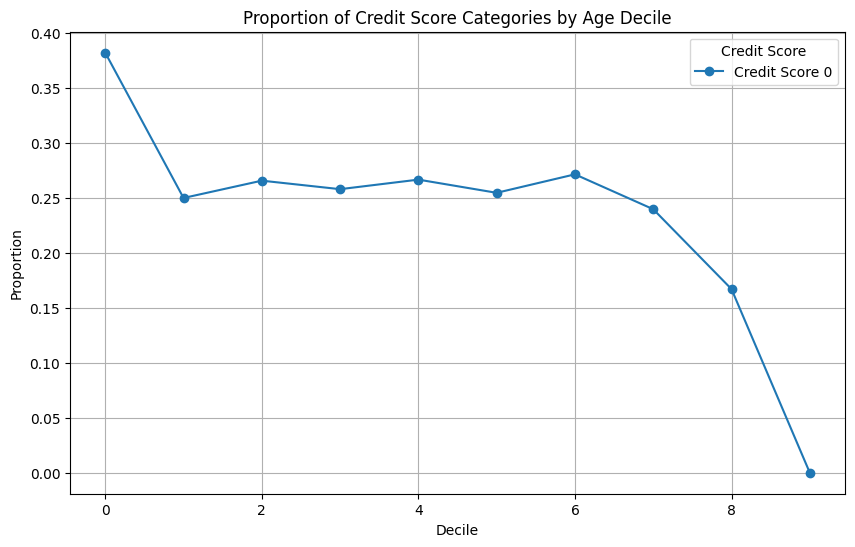

<Figure size 1000x600 with 0 Axes>

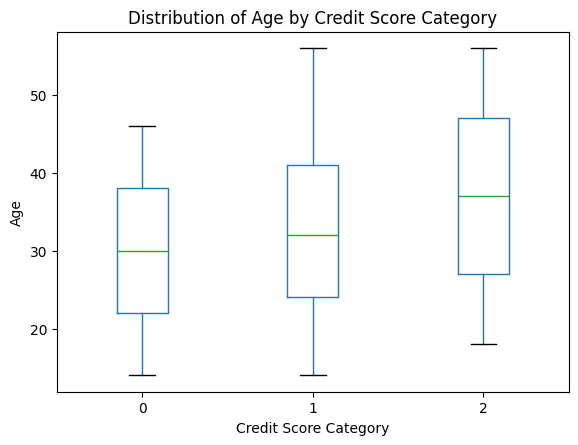

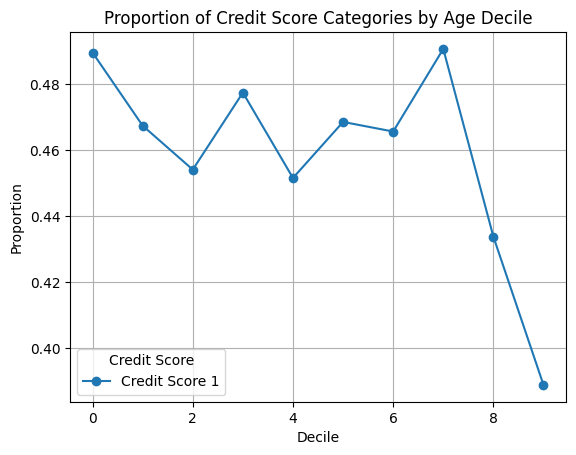

<Figure size 1000x600 with 0 Axes>

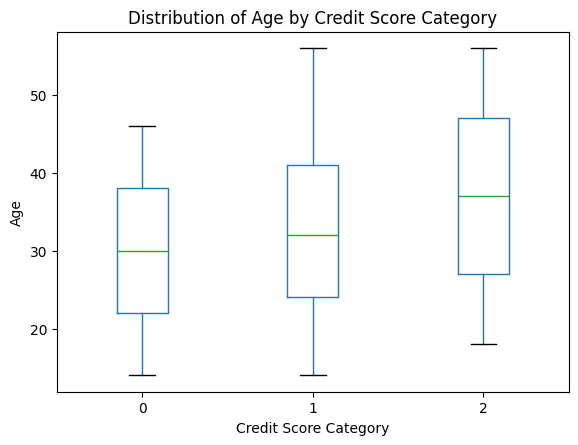

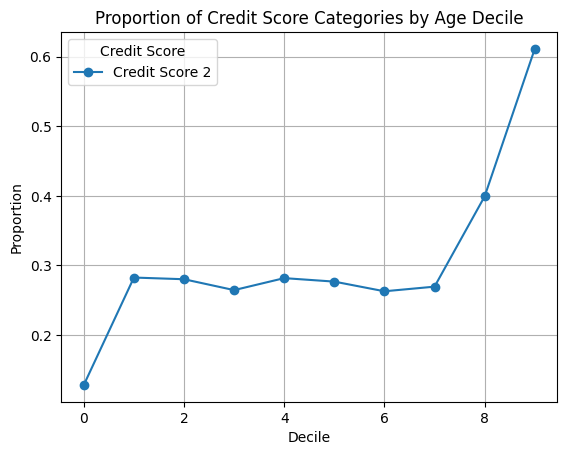

<Figure size 1000x600 with 0 Axes>

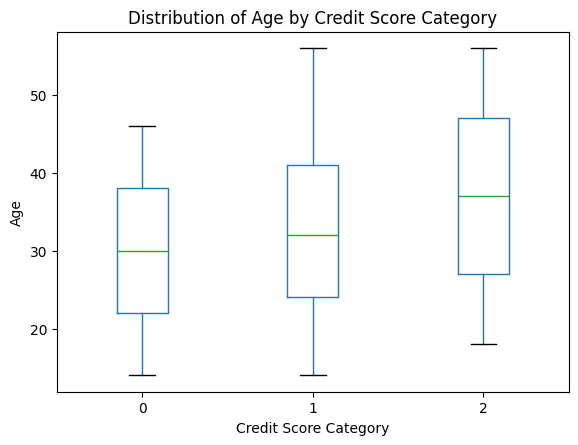

In [ ]:
import matplotlib.pyplot as plt

# Plot line chart showing proportion trends of each Credit_Score category across deciles
plt.figure(figsize=(10, 6))

for category in category_proportions.columns:
    category_proportions[category], marker='o', label=f"Credit Score {category}")

    plt.xlabel("Decile")
    plt.ylabel("Proportion")
    plt.title("Proportion of Credit Score Categories by Age Decile")
    plt.legend(titplt.plot(category_proportions.index, le="Credit Score")
    plt.grid(True)
    plt.show()

    # Boxplot to visualize the distribution of Age across Credit Score categories
    plt.figure(figsize=(10, 6))
    df.boxplot(column="Age", by="Credit_Score", grid=False)
    plt.title("Distribution of Age by Credit Score Category")
    plt.suptitle("")
    plt.xlabel("Credit Score Category")
    plt.ylabel("Age")
    plt.show()


In [ ]:
# POR ACÁ! DEVOLVERME A LA GENERACIÓN DEL DATASET PARA CONVERTIR EN NUMÉRICAS LAS VARIABLES BOOLEANAS
# CONTINUAR EL ANÁLISIS BIVARIADO